# Plate Solve Test
Uses `platesolve.create_solver` → selects backend → WCS

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from platesolve import create_solver

## 1. Load image

Shape: (3000, 3000, 4)  dtype: uint8


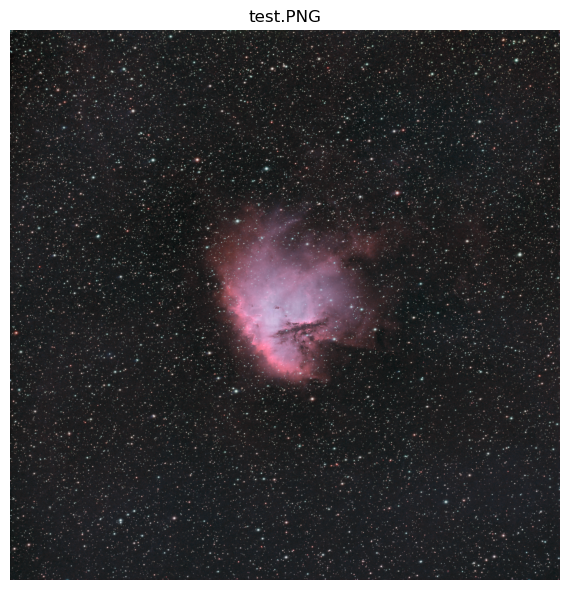

In [2]:
IMAGE_PATH = "test.PNG"

img = np.array(Image.open(IMAGE_PATH))
print(f"Shape: {img.shape}  dtype: {img.dtype}")

plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray' if img.ndim == 2 else None)
plt.axis('off')
plt.title(IMAGE_PATH)
plt.tight_layout()
plt.show()

## 2. Plate solve
Get a free API key at https://nova.astrometry.net/api_help — put it in `.env` as `ASTROMETRY_API_KEY`.

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.environ.get("ASTROMETRY_API_KEY", "")
if not API_KEY:
    raise ValueError("Set ASTROMETRY_API_KEY in .env")

BACKEND = "astrometry_net"  # swap to another registered solver here

solver = create_solver(BACKEND, api_key=API_KEY)

# Optional hints to speed up the solve:
# result = solver.solve(img, scale_units='arcsecperpix', scale_lower=0.5, scale_upper=2.0)
#if result already has a solution, you can skip the solve step and just print the result:
result = solver.solve(img)

Submitted (subid=14948050), waiting for job…
Job 15784006 assigned, solving…
Solved! Fetching WCS…


## 3. Inspect WCS

Pixel (0,0)  → RA=15.1557°  Dec=57.8503°
Center pixel → RA=13.2149°  Dec=56.6566°


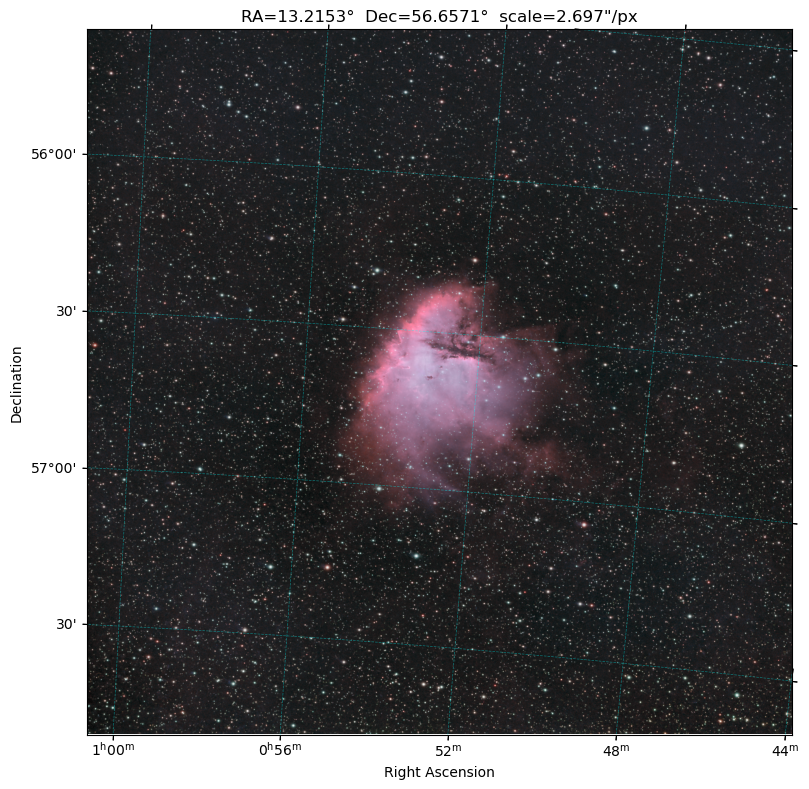

In [5]:
wcs = result.wcs

sky = wcs.pixel_to_world(0, 0)
print(f"Pixel (0,0)  → RA={sky.ra.deg:.4f}°  Dec={sky.dec.deg:.4f}°")

h, w = img.shape[:2]
sky_center = wcs.pixel_to_world(w / 2, h / 2)
print(f"Center pixel → RA={sky_center.ra.deg:.4f}°  Dec={sky_center.dec.deg:.4f}°")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=wcs)
ax.imshow(img, cmap='gray' if img.ndim == 2 else None, origin='lower')
ax.grid(color='cyan', alpha=0.4, linestyle='--', linewidth=0.5)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.set_title(f"RA={result.ra:.4f}°  Dec={result.dec:.4f}°  scale={result.pixscale:.3f}\"/px")
plt.tight_layout()
plt.show()

## 4. Save WCS + Image to FITS
Save the plate-solved image with WCS information as a FITS file


In [6]:
from astropy.io import fits

# Convert image to appropriate format for FITS
img_for_fits = np.array(img[:,:,:3], dtype=np.float32)
#put channel to the first dimension for FITS (N, H, W)
img_for_fits = np.transpose(img_for_fits, (2, 0, 1))
# Create Primary HDU with image data
hdu = fits.PrimaryHDU(data=img_for_fits)

# Get WCS header and add to HDU
header = wcs.to_header()
hdu.header.update(header)

# Add some metadata
hdu.header['COMMENT'] = 'Plate-solved image with WCS information'
hdu.header['SOLVER'] = 'Astrometry.net'

# Create HDUList and save
hdul = fits.HDUList([hdu])
output_fits = IMAGE_PATH.replace('.PNG', '_solved.fits').replace('.png', '_solved.fits')
hdul.writeto(output_fits, overwrite=True)

print(f"✓ FITS file saved: {output_fits}")
print(f"  Image shape: {img_for_fits.shape}")
print(f"  WCS info: RA={wcs.wcs.crval[0]:.4f}°, Dec={wcs.wcs.crval[1]:.4f}°")

✓ FITS file saved: test_solved.fits
  Image shape: (3, 3000, 3000)
  WCS info: RA=12.9067°, Dec=57.3628°
